In [26]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [27]:
data = pd.read_csv("heart_failure_clinical_records_dataset.csv")

In [28]:
X = data.drop("DEATH_EVENT", axis=1)
y = data["DEATH_EVENT"]


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,test_size=0.20,random_state=42,stratify=y)

In [30]:
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", C=1))
])

svm_model.fit(X_train, y_train)
predictions = svm_model.predict(X_test)

In [31]:
X_2d = data[["age", "ejection_fraction"]]
y = data["DEATH_EVENT"]


svm_2d = SVC(C=1, kernel="linear")
svm_2d.fit(X_2d, y)

,C,1
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


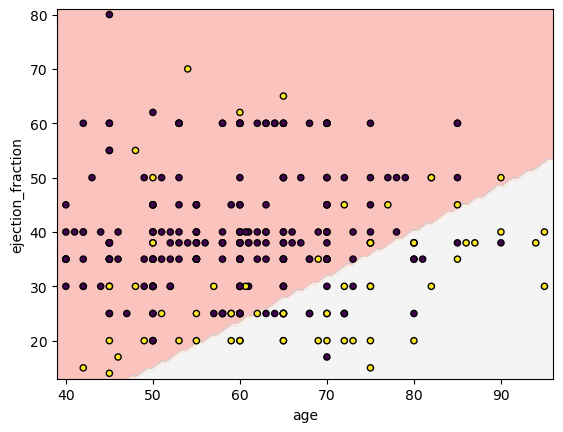

In [32]:
DecisionBoundaryDisplay.from_estimator(
    svm_2d,
    X_2d,
    response_method="predict",
    alpha=0.8,
    cmap="Pastel1",
    xlabel="age",
    ylabel="ejection_fraction",
)

plt.scatter(
    X_2d["age"],
    X_2d["ejection_fraction"],
    c=y,
    s=20,
    edgecolors="k"
)

plt.show()

In [33]:
results = []

def evaluate_model(name, model):

    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    print(f"\n{name}")
    print("="*50)
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)

    print("\nClassification Report:")
    print(classification_report(y_test, predictions))

    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

    return model


Linear SVM
Accuracy: 0.7833333333333333
Precision: 0.8
Recall: 0.42105263157894735
F1 Score: 0.5517241379310345

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.95      0.86        41
           1       0.80      0.42      0.55        19

    accuracy                           0.78        60
   macro avg       0.79      0.69      0.70        60
weighted avg       0.79      0.78      0.76        60



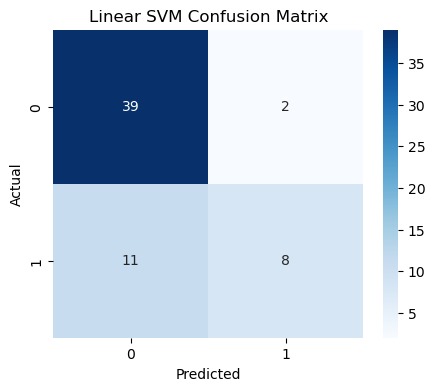

,steps,"[('scaler', ...), ('svm', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1
,kernel,'linear'
,degree,3
,gamma,'scale'


In [34]:
evaluate_model("Linear SVM", svm_model)

In [35]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Linear SVM,0.783333,0.8,0.421053,0.551724
